# SCLC CIN 预测模型 — 全流程复现（固定 seed=152）

一条命令从原始数据跑到最终图表，无种子筛选循环。

**流程**：
1. 加载数据 + 患者级划分（seed=152）
2. 特征选择（MICE → IsoForest → Boruta → LASSO → 交集 6 特征）
3. HPO（折内 MICE + 患者级早停）
4. 5 折集成 + 测试评估
5. 全部图表 + 表格

**方法学**：折内 MICE（无泄漏）、IsoForest(0.05)、StratifiedGroupKFold 分层、患者级早停、患者级 cluster bootstrap、5 折集成。

In [ ]:
############################################################
# reproduce_full.py — 全流程复现脚本（固定 seed=152，无种子筛选）
#
# 一条命令从原始数据跑到最终图表：
#   python reproduce_full.py
#
# 流程：
#   1. 加载 SCLC数据.xlsx → 患者级划分（seed=152）
#   2. 特征选择：MICE → IsoForest → Boruta(20次) → LASSO(λ_min) → 交集 6 特征
#   3. HPO：折内 MICE + 患者级早停，Optuna 100 trials（有缓存则跳过）
#   4. 5 折集成 + 测试集验证（患者级 bootstrap + 三阈值）
#   5. 全部图表 + 表格
#
# 方法学要点：折内 MICE（无泄漏）、IsoForest(0.05)、StratifiedGroupKFold 分层、
#            患者级早停、患者级 cluster bootstrap、5 折集成（CV=测试口径一致）
############################################################

import sys, os, pickle, time, warnings
warnings.filterwarnings("ignore")
try: sys.stdout.reconfigure(encoding='utf-8')
except: pass
if "__file__" in globals():
    os.chdir(os.path.dirname(os.path.abspath(__file__)))

import numpy as np
import pandas as pd
import matplotlib
_in_notebook = False
try:
    from IPython import get_ipython
    _in_notebook = get_ipython() is not None
except Exception:
    pass
if not _in_notebook:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.metrics import (roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score, confusion_matrix,
                             accuracy_score, f1_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import PartialDependenceDisplay
from boruta import BorutaPy
import shap
from lime import lime_tabular

## 全局配置

In [2]:
SEED = 152
TEST_SIZE = 0.20
RANDOM_STATE = 66
MICE_SEED = 66
ISO_CONTAM = 0.05
CATEGORY_COLS = ["Gender", "Chemotherapy regimen"]
BORUTA_REPEAT = 20
BORUTA_THRESHOLD = 4
INNER_EVAL_RATIO = 0.15
N_TRIALS = 100
N_JOBS = 8
STUDY_NAME = "catboost_final_v3"
BEST_PARAMS_PKL = "best_params_final_v3.pkl"

plt.rcParams.update({"font.family": "Times New Roman", "axes.unicode_minus": False,
                     "axes.titlesize": 16, "axes.labelsize": 14,
                     "xtick.labelsize": 12, "ytick.labelsize": 12,
                     "legend.fontsize": 12})

def save_fig(name, dpi=600):
    """保存当前 figure 为 png+pdf，打印路径，并内联显示（notebook）。"""
    paths = []
    for ext in ("png", "pdf"):
        p = os.path.join(os.getcwd(), f"{name}.{ext}")
        plt.savefig(p, dpi=dpi, bbox_inches="tight")
        paths.append(p)
    if _in_notebook:
        plt.show()
    plt.close()
    print(f"  [Saved] {paths[0]}")
    print(f"  [Saved] {paths[1]}")

t0 = time.time()
print("=" * 70)
print(f"全流程复现：固定 seed={SEED}，无种子筛选")
print("=" * 70)

全流程复现：固定 seed=152，无种子筛选


## Step 1：加载数据 + 患者级划分

In [ ]:
print("\n[Step 1] 加载数据 + 患者级划分（seed=152）...")
df = pd.read_excel("SCLC数据.xlsx")
for col in CATEGORY_COLS:
    df[col] = df[col].astype("category").cat.codes
patient_ids = df["patient_id"]
target = df["CIN"]
X = df.drop(columns=["CIN", "patient_id"])

unique_patients = patient_ids.unique()
train_patients, test_patients = train_test_split(
    unique_patients, test_size=TEST_SIZE, random_state=SEED)
train_mask = patient_ids.isin(train_patients)
test_mask = patient_ids.isin(test_patients)
X_train = X.loc[train_mask].copy(); y_train = target.loc[train_mask].copy()
X_test = X.loc[test_mask].copy(); y_test = target.loc[test_mask].copy()
train_pid = patient_ids.loc[train_mask]; test_pid = patient_ids.loc[test_mask]
print(f"  训练 {len(y_train)} 周期 / {train_pid.nunique()} 患者 | 测试 {len(y_test)} 周期 / {test_pid.nunique()} 患者")

# 队列表
cohort_table = pd.DataFrame({
    "Cohort": ["Training", "Test", "Total"],
    "Patients": [train_pid.nunique(), test_pid.nunique(), train_pid.nunique() + test_pid.nunique()],
    "Cycles": [len(y_train), len(y_test), len(y_train) + len(y_test)],
    "CIN events": [int(y_train.sum()), int(y_test.sum()), int(y_train.sum() + y_test.sum())],
    "CIN rate": [f"{y_train.mean():.1%}", f"{y_test.mean():.1%}", f"{(y_train.sum()+y_test.sum())/(len(y_train)+len(y_test)):.1%}"],
})
cohort_table.to_excel("final_cohort_table.xlsx", index=False)
print(cohort_table.to_string(index=False))


[Step 1] 加载数据 + 患者级划分（seed=152）...
  训练 681 周期 / 167 患者 | 测试 159 周期 / 42 患者
  Cohort  Patients  Cycles  CIN events CIN rate
Training       167     681         191    28.0%
    Test        42     159          40    25.2%
   Total       209     840         231    27.5%


## Step 2：特征选择

In [4]:
print("\n[Step 2] 特征选择（MICE → IsoForest → Boruta → LASSO）...")
cat_cols_mice = [c for c in CATEGORY_COLS if c in X_train.columns]
X_train_cat = X_train[cat_cols_mice].copy(); X_test_cat = X_test[cat_cols_mice].copy()
X_train_cont = X_train.drop(columns=cat_cols_mice); X_test_cont = X_test.drop(columns=cat_cols_mice)
mice = IterativeImputer(random_state=MICE_SEED, max_iter=10)
X_train_imp = pd.DataFrame(mice.fit_transform(X_train_cont), columns=X_train_cont.columns, index=X_train_cont.index)
X_test_imp = pd.DataFrame(mice.transform(X_test_cont), columns=X_test_cont.columns, index=X_test_cont.index)
X_train_imp = pd.concat([X_train_imp, X_train_cat], axis=1)[X_train.columns.tolist()]
X_test_imp = pd.concat([X_test_imp, X_test_cat], axis=1)[X_test.columns.tolist()]

iso = IsolationForest(n_estimators=100, contamination=ISO_CONTAM, random_state=MICE_SEED)
keep = iso.fit_predict(X_train_imp) == 1
X_train_clean = X_train_imp.loc[keep].copy(); y_train_clean = y_train.loc[keep].copy()
train_pid_clean = train_pid.loc[keep].copy()
print(f"  IsoForest 删除 {int((~keep).sum())} 个训练样本，剩余 {len(X_train_clean)}")

# Boruta 20 次
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)
sel_count = pd.Series(0, index=X_train_clean.columns, dtype=int)
for i in range(BORUTA_REPEAT):
    bor = BorutaPy(rf, n_estimators='auto', verbose=0, random_state=i, max_iter=50)
    bor.fit(X_train_clean.values, y_train_clean.values)
    sel_count += (pd.Series(bor.ranking_, index=X_train_clean.columns) == 1)
boruta_features = sel_count[sel_count >= BORUTA_THRESHOLD].index.tolist()

# LASSO λ_min（患者级 CV）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_clean)
sgkf_lasso = StratifiedGroupKFold(n_splits=5)
cv_splits = list(sgkf_lasso.split(X_scaled, y_train_clean, groups=train_pid_clean.values))
lcv = LassoCV(alphas=np.logspace(-4, 0, 50), cv=cv_splits, random_state=66, max_iter=10000)
lcv.fit(X_scaled, y_train_clean)
lm = Lasso(alpha=lcv.alpha_, max_iter=10000)
lm.fit(X_scaled, y_train_clean)
lasso_features = X_train_clean.columns[lm.coef_ != 0].tolist()

features = sorted(set(boruta_features) & set(lasso_features))
if not features:
    features = boruta_features
print(f"  Boruta 选中 {len(boruta_features)} 个，LASSO 选中 {len(lasso_features)} 个")
print(f"  交集特征（{len(features)}个）: {features}")
cat_ids = [i for i, c in enumerate(features) if c in CATEGORY_COLS]
print(f"  类别特征索引: {cat_ids}")


[Step 2] 特征选择（MICE → IsoForest → Boruta → LASSO）...
  IsoForest 删除 34 个训练样本，剩余 647
  Boruta 选中 6 个，LASSO 选中 12 个
  交集特征（6个）: ['Absolute neutrophil count', 'Chemotherapy cycle', 'Chemotherapy regimen', 'Glomerular filtration rate', 'Prophylactic medication', 'Rescue treatment in the prior cycle']
  类别特征索引: [2]


## 折内清洗函数

In [5]:
def clean_fold(X_ft_raw, X_fv_raw, X_te_raw=None):
    cc = [c for c in CATEGORY_COLS if c in X_ft_raw.columns]
    ftc = X_ft_raw[cc].copy() if cc else None
    fvc = X_fv_raw[cc].copy() if cc else None
    tec = X_te_raw[cc].copy() if (X_te_raw is not None and cc) else None
    ftn = X_ft_raw.drop(columns=cc, errors='ignore')
    fvn = X_fv_raw.drop(columns=cc, errors='ignore')
    ten = X_te_raw.drop(columns=cc, errors='ignore') if X_te_raw is not None else None
    mi = IterativeImputer(random_state=MICE_SEED, max_iter=10)
    ftn = pd.DataFrame(mi.fit_transform(ftn), columns=ftn.columns, index=ftn.index)
    fvn = pd.DataFrame(mi.transform(fvn), columns=fvn.columns, index=fvn.index)
    if ten is not None:
        ten = pd.DataFrame(mi.transform(ten), columns=ten.columns, index=ten.index)
    X_ft = pd.concat([ftn, ftc], axis=1)[X_ft_raw.columns.tolist()] if ftc is not None else ftn
    X_fv = pd.concat([fvn, fvc], axis=1)[X_fv_raw.columns.tolist()] if fvc is not None else fvn
    if ten is not None:
        X_te = pd.concat([ten, tec], axis=1)[X_te_raw.columns.tolist()] if tec is not None else ten
    iso = IsolationForest(n_estimators=100, contamination=ISO_CONTAM, random_state=MICE_SEED)
    X_ft = X_ft.loc[iso.fit_predict(X_ft) == 1].copy()
    return (X_ft, X_fv, X_te) if X_te_raw is not None else (X_ft, X_fv)

def patient_level_split(X, y, pid, test_size, random_state):
    up = pid.unique()
    pl = np.array([y[pid == p].iloc[0] for p in up])
    tp, ep = train_test_split(up, test_size=test_size, random_state=random_state, stratify=pl)
    tm = pid.isin(tp).values
    return tm, ~tm

gkf = StratifiedGroupKFold(n_splits=5)

## Step 3：HPO

In [6]:
print("\n[Step 3] HPO（折内 MICE + 患者级早停）...")
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SPACE = {
    "learning_rate":       ("float", 0.01, 0.30),
    "depth":               ("int",   3, 8),
    "l2_leaf_reg":         ("float", 1e-3, 10.0),
    "iterations":          ("int",   200, 1200),
    "border_count":        ("int",   32, 255),
    "bagging_temperature": ("float", 0.0, 1.0),
    "random_strength":     ("float", 1.0, 20.0),
    "min_data_in_leaf":    ("int",   5, 30),
}

if os.path.exists(BEST_PARAMS_PKL):
    bp = pickle.load(open(BEST_PARAMS_PKL, "rb"))
    best_params = bp["best_params"]; hpo_cv_auc = bp["best_cv_auc"]
    print(f"  已加载 {BEST_PARAMS_PKL}，HPO 5折CV-AUC = {hpo_cv_auc:.4f}")
else:
    print(f"  开始 HPO（{N_TRIALS} trials, n_jobs={N_JOBS}）...")
    fold_cache = []
    for tr, va in gkf.split(X_train, y_train, groups=train_pid.values):
        X_ft, X_fv = clean_fold(X_train.iloc[tr].copy(), X_train.iloc[va].copy())
        y_ft = y_train.iloc[tr].loc[X_ft.index]; y_fv = y_train.iloc[va]
        pid_ft = train_pid.iloc[tr].loc[X_ft.index]
        fold_cache.append((X_ft[features], y_ft, X_fv[features], y_fv, pid_ft))

    def suggest(trial):
        p = {}
        for name, spec in SPACE.items():
            kind, lo, hi = spec[0], spec[1], spec[2]
            p[name] = trial.suggest_float(name, lo, hi, log=(lo > 0)) if kind == "float" else trial.suggest_int(name, lo, hi)
        return p

    def objective(trial):
        params = suggest(trial); aucs = []
        for X_ft, y_ft, X_fv, y_fv, pid_ft in fold_cache:
            tr_mask, ev_mask = patient_level_split(X_ft, y_ft, pid_ft, INNER_EVAL_RATIO, RANDOM_STATE)
            m = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0, task_type="CPU",
                                   cat_features=cat_ids, eval_metric="AUC",
                                   early_stopping_rounds=30, **params)
            m.fit(X_ft[tr_mask], y_ft[tr_mask], eval_set=(X_ft[ev_mask], y_ft[ev_mask]))
            aucs.append(roc_auc_score(y_fv, m.predict_proba(X_fv)[:, 1]))
        return float(np.mean(aucs))

    study = optuna.create_study(direction="maximize", study_name=STUDY_NAME,
                                storage="sqlite:///optuna_final_hpo.db", load_if_exists=True)
    study.optimize(objective, n_trials=N_TRIALS, n_jobs=N_JOBS)
    best_params = study.best_params; hpo_cv_auc = study.best_value
    pickle.dump({"best_params": best_params, "best_cv_auc": hpo_cv_auc,
                 "seed": SEED, "features": features}, open(BEST_PARAMS_PKL, "wb"))
    print(f"  HPO 完成，最优 5折CV-AUC = {hpo_cv_auc:.4f}")
print(f"  最优参数: {best_params}")


[Step 3] HPO（折内 MICE + 患者级早停）...
  已加载 best_params_final_v3.pkl，HPO 5折CV-AUC = 0.7673
  最优参数: {'learning_rate': 0.017370320822004185, 'depth': 7, 'l2_leaf_reg': 4.074493001245239, 'iterations': 1063, 'border_count': 43, 'bagging_temperature': 0.38871036409090637, 'random_strength': 1.8785040292889266, 'min_data_in_leaf': 26}


## Step 4：5 折集成 + 测试评估

In [7]:
print("\n[Step 4] 5 折集成训练 + 测试评估...")
fold_models, fold_aucs, test_probas = [], [], []
oof_proba = np.zeros(len(y_train))
X_te_ref = None
for fi, (tr, va) in enumerate(gkf.split(X_train, y_train, groups=train_pid.values)):
    X_ft_raw = X_train.iloc[tr].copy(); X_fv_raw = X_train.iloc[va].copy()
    y_ft_raw = y_train.iloc[tr]; y_fv = y_train.iloc[va]
    X_ft, X_fv, X_te = clean_fold(X_ft_raw, X_fv_raw, X_test.copy())
    y_ft = y_ft_raw.loc[X_ft.index]
    pid_ft = train_pid.iloc[tr].loc[X_ft.index]
    X_ft5, X_fv5, X_te5 = X_ft[features], X_fv[features], X_te[features]
    if fi == 0: X_te_ref = X_te5.copy()
    tr_mask, ev_mask = patient_level_split(X_ft5, y_ft, pid_ft, INNER_EVAL_RATIO, RANDOM_STATE)
    m = CatBoostClassifier(random_state=RANDOM_STATE, verbose=0, task_type="CPU",
                           cat_features=cat_ids, eval_metric="AUC",
                           early_stopping_rounds=30, **best_params)
    m.fit(X_ft5[tr_mask], y_ft[tr_mask], eval_set=(X_ft5[ev_mask], y_ft[ev_mask]))
    fold_models.append(m)
    fold_aucs.append(roc_auc_score(y_fv, m.predict_proba(X_fv5)[:, 1]))
    test_probas.append(m.predict_proba(X_te5)[:, 1])
    oof_proba[va] = m.predict_proba(X_fv5)[:, 1]
    print(f"  fold{fi}: val AUC={fold_aucs[-1]:.4f}  trees={m.tree_count_}")

proba_ens = np.mean(test_probas, axis=0)
cv_auc, cv_std = np.mean(fold_aucs), np.std(fold_aucs)
test_auc = roc_auc_score(y_test, proba_ens)
test_auprc = average_precision_score(y_test, proba_ens)
oof_auc = roc_auc_score(y_train, oof_proba)
print(f"\n  5折CV-AUC = {cv_auc:.4f} ± {cv_std:.4f}  (OOF-AUC = {oof_auc:.4f})")
print(f"  测试集 AUC = {test_auc:.4f}  测试 AUPRC = {test_auprc:.4f}")

# 患者级 cluster bootstrap
def boot_ci_cluster(yt, pr, fn, patient_ids, n_iter=2000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    up = patient_ids.unique()
    vals = []
    for _ in range(n_iter):
        sampled = rng.choice(up, size=len(up), replace=True)
        mask = patient_ids.isin(sampled).values
        if yt[mask].nunique() < 2:
            continue
        vals.append(fn(yt[mask], pr[mask]))
    return np.percentile(np.array(vals), [2.5, 97.5])

auc_ci = boot_ci_cluster(y_test, proba_ens, roc_auc_score, test_pid)
auprc_ci = boot_ci_cluster(y_test, proba_ens, average_precision_score, test_pid)

# 三阈值（OOF 确定）
oof_fpr, oof_tpr, oof_thr = roc_curve(y_train, oof_proba)
youden_thr = oof_thr[np.argmax(oof_tpr - oof_fpr)]
sens_mask = oof_tpr >= 0.75
high_sens_thr = oof_thr[sens_mask][np.argmax(1 - oof_fpr[sens_mask])] if sens_mask.any() else youden_thr
spec_mask = (1 - oof_fpr) >= 0.80
high_spec_thr = oof_thr[spec_mask][np.argmax(oof_tpr[spec_mask])] if spec_mask.any() else youden_thr

def thr_metrics(yt, pr, thr):
    pred = (pr >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    ppv = tp / (tp + fp) if (tp + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan
    acc = accuracy_score(yt, pred)
    f1 = f1_score(yt, pred)
    return tn, fp, fn, tp, sens, spec, ppv, npv, acc, f1

def sens_at(thr):
    def _f(yt, pr): return thr_metrics(yt, pr, thr)[4]
    return _f
def spec_at(thr):
    def _f(yt, pr): return thr_metrics(yt, pr, thr)[5]
    return _f
def acc_at(thr):
    def _f(yt, pr): return thr_metrics(yt, pr, thr)[8]
    return _f
def ppv_at(thr):
    def _f(yt, pr): return thr_metrics(yt, pr, thr)[6]
    return _f
def f1_at(thr):
    def _f(yt, pr): return thr_metrics(yt, pr, thr)[9]
    return _f

thresholds = [
    ("Youden", youden_thr),
    ("Screening (sens>=0.75)", high_sens_thr),
    ("Confirmatory (spec>=0.80)", high_spec_thr),
]
thr_rows = []
for name, thr in thresholds:
    tn, fp, fn, tp, sens, spec, ppv, npv, acc, f1 = thr_metrics(y_test, proba_ens, thr)
    s_ci = boot_ci_cluster(y_test, proba_ens, sens_at(thr), test_pid)
    sp_ci = boot_ci_cluster(y_test, proba_ens, spec_at(thr), test_pid)
    a_ci = boot_ci_cluster(y_test, proba_ens, acc_at(thr), test_pid)
    p_ci = boot_ci_cluster(y_test, proba_ens, ppv_at(thr), test_pid)
    f_ci = boot_ci_cluster(y_test, proba_ens, f1_at(thr), test_pid)
    thr_rows.append({"Threshold": name, "cutoff": round(thr, 3),
                     "Accuracy": f"{acc:.3f} ({a_ci[0]:.3f},{a_ci[1]:.3f})",
                     "Sensitivity": f"{sens:.3f} ({s_ci[0]:.3f},{s_ci[1]:.3f})",
                     "Specificity": f"{spec:.3f} ({sp_ci[0]:.3f},{sp_ci[1]:.3f})",
                     "PPV": f"{ppv:.3f} ({p_ci[0]:.3f},{p_ci[1]:.3f})",
                     "F1": f"{f1:.3f} ({f_ci[0]:.3f},{f_ci[1]:.3f})"})
thr_df = pd.DataFrame(thr_rows)
thr_df.to_excel("final_thresholds.xlsx", index=False)

best_thr = youden_thr
tn, fp, fn, tp, sens, spec, ppv, npv, acc, f1 = thr_metrics(y_test, proba_ens, best_thr)
brier = brier_score_loss(y_test, proba_ens)
fpr, tpr, thresh = roc_curve(y_test, proba_ens)

print(f"  测试 AUC 95%CI = [{auc_ci[0]:.4f}, {auc_ci[1]:.4f}]")
print(f"  测试 AUPRC 95%CI = [{auprc_ci[0]:.4f}, {auprc_ci[1]:.4f}]")
print("\n  三阈值（OOF 确定，测试集如实报告）：")
print(thr_df.to_string(index=False))


[Step 4] 5 折集成训练 + 测试评估...
  fold0: val AUC=0.7436  trees=173
  fold1: val AUC=0.7733  trees=17
  fold2: val AUC=0.7784  trees=2
  fold3: val AUC=0.7824  trees=23
  fold4: val AUC=0.7591  trees=99

  5折CV-AUC = 0.7673 ± 0.0143  (OOF-AUC = 0.7008)
  测试集 AUC = 0.7521  测试 AUPRC = 0.5554
  测试 AUC 95%CI = [0.6898, 0.8158]
  测试 AUPRC 95%CI = [0.4479, 0.6501]

  三阈值（OOF 确定，测试集如实报告）：
                Threshold  cutoff            Accuracy         Sensitivity         Specificity                 PPV                  F1
                   Youden   0.441 0.736 (0.680,0.793) 0.475 (0.375,0.591) 0.824 (0.769,0.878) 0.475 (0.381,0.577) 0.475 (0.386,0.558)
   Screening (sens>=0.75)   0.410 0.730 (0.673,0.793) 0.600 (0.476,0.741) 0.773 (0.705,0.843) 0.471 (0.387,0.552) 0.527 (0.435,0.607)
Confirmatory (spec>=0.80)   0.486 0.761 (0.704,0.822) 0.350 (0.231,0.476) 0.899 (0.859,0.941) 0.538 (0.400,0.667) 0.424 (0.304,0.531)


## Step 5：图表


[Step 5] 生成图表...


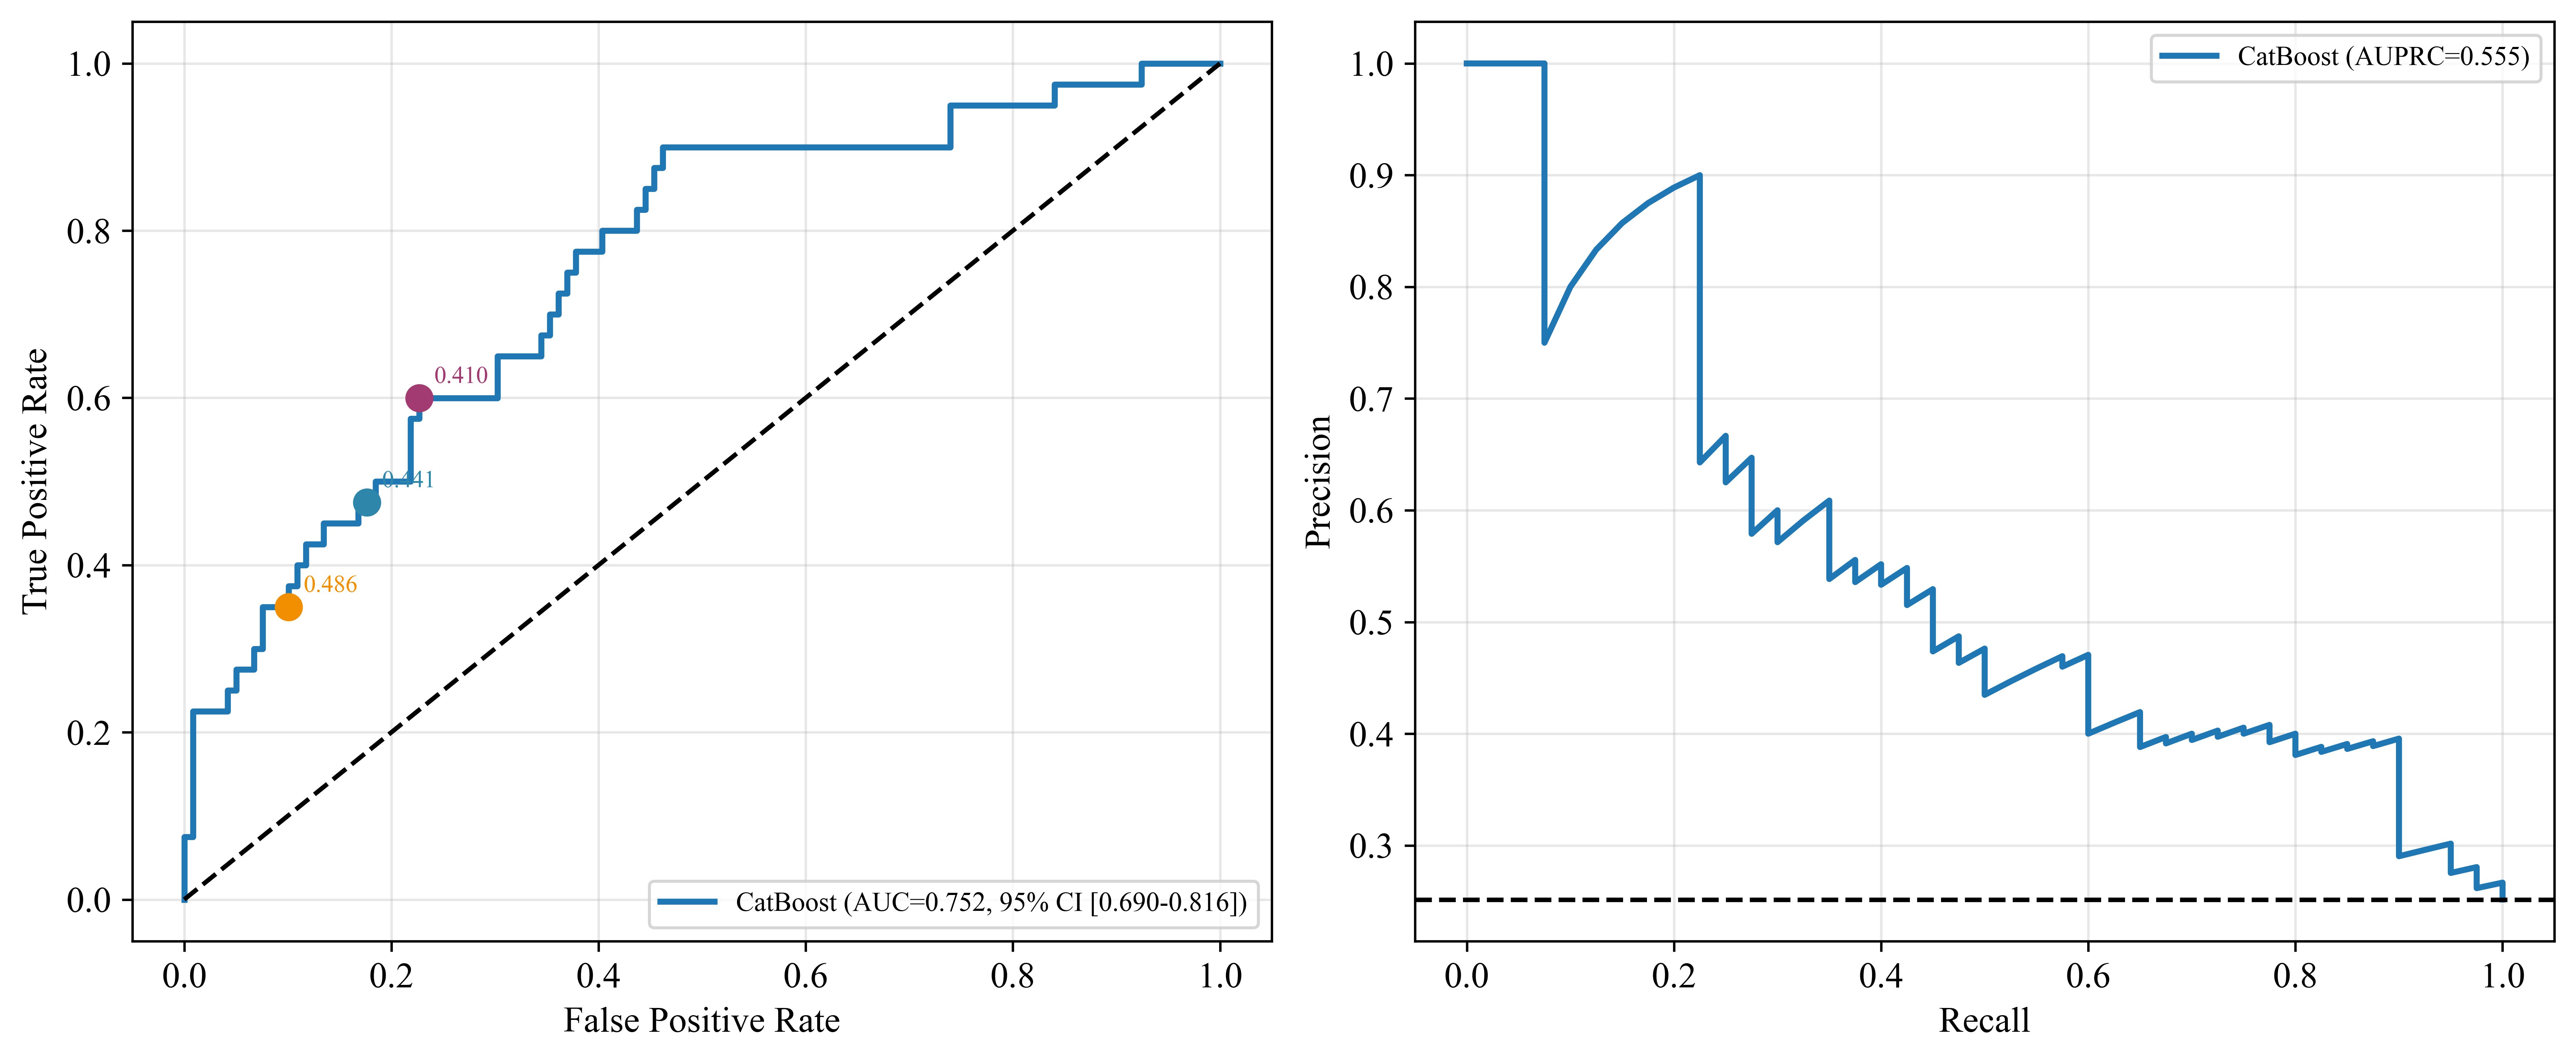

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure3B_ROC_PR.png
  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure3B_ROC_PR.pdf


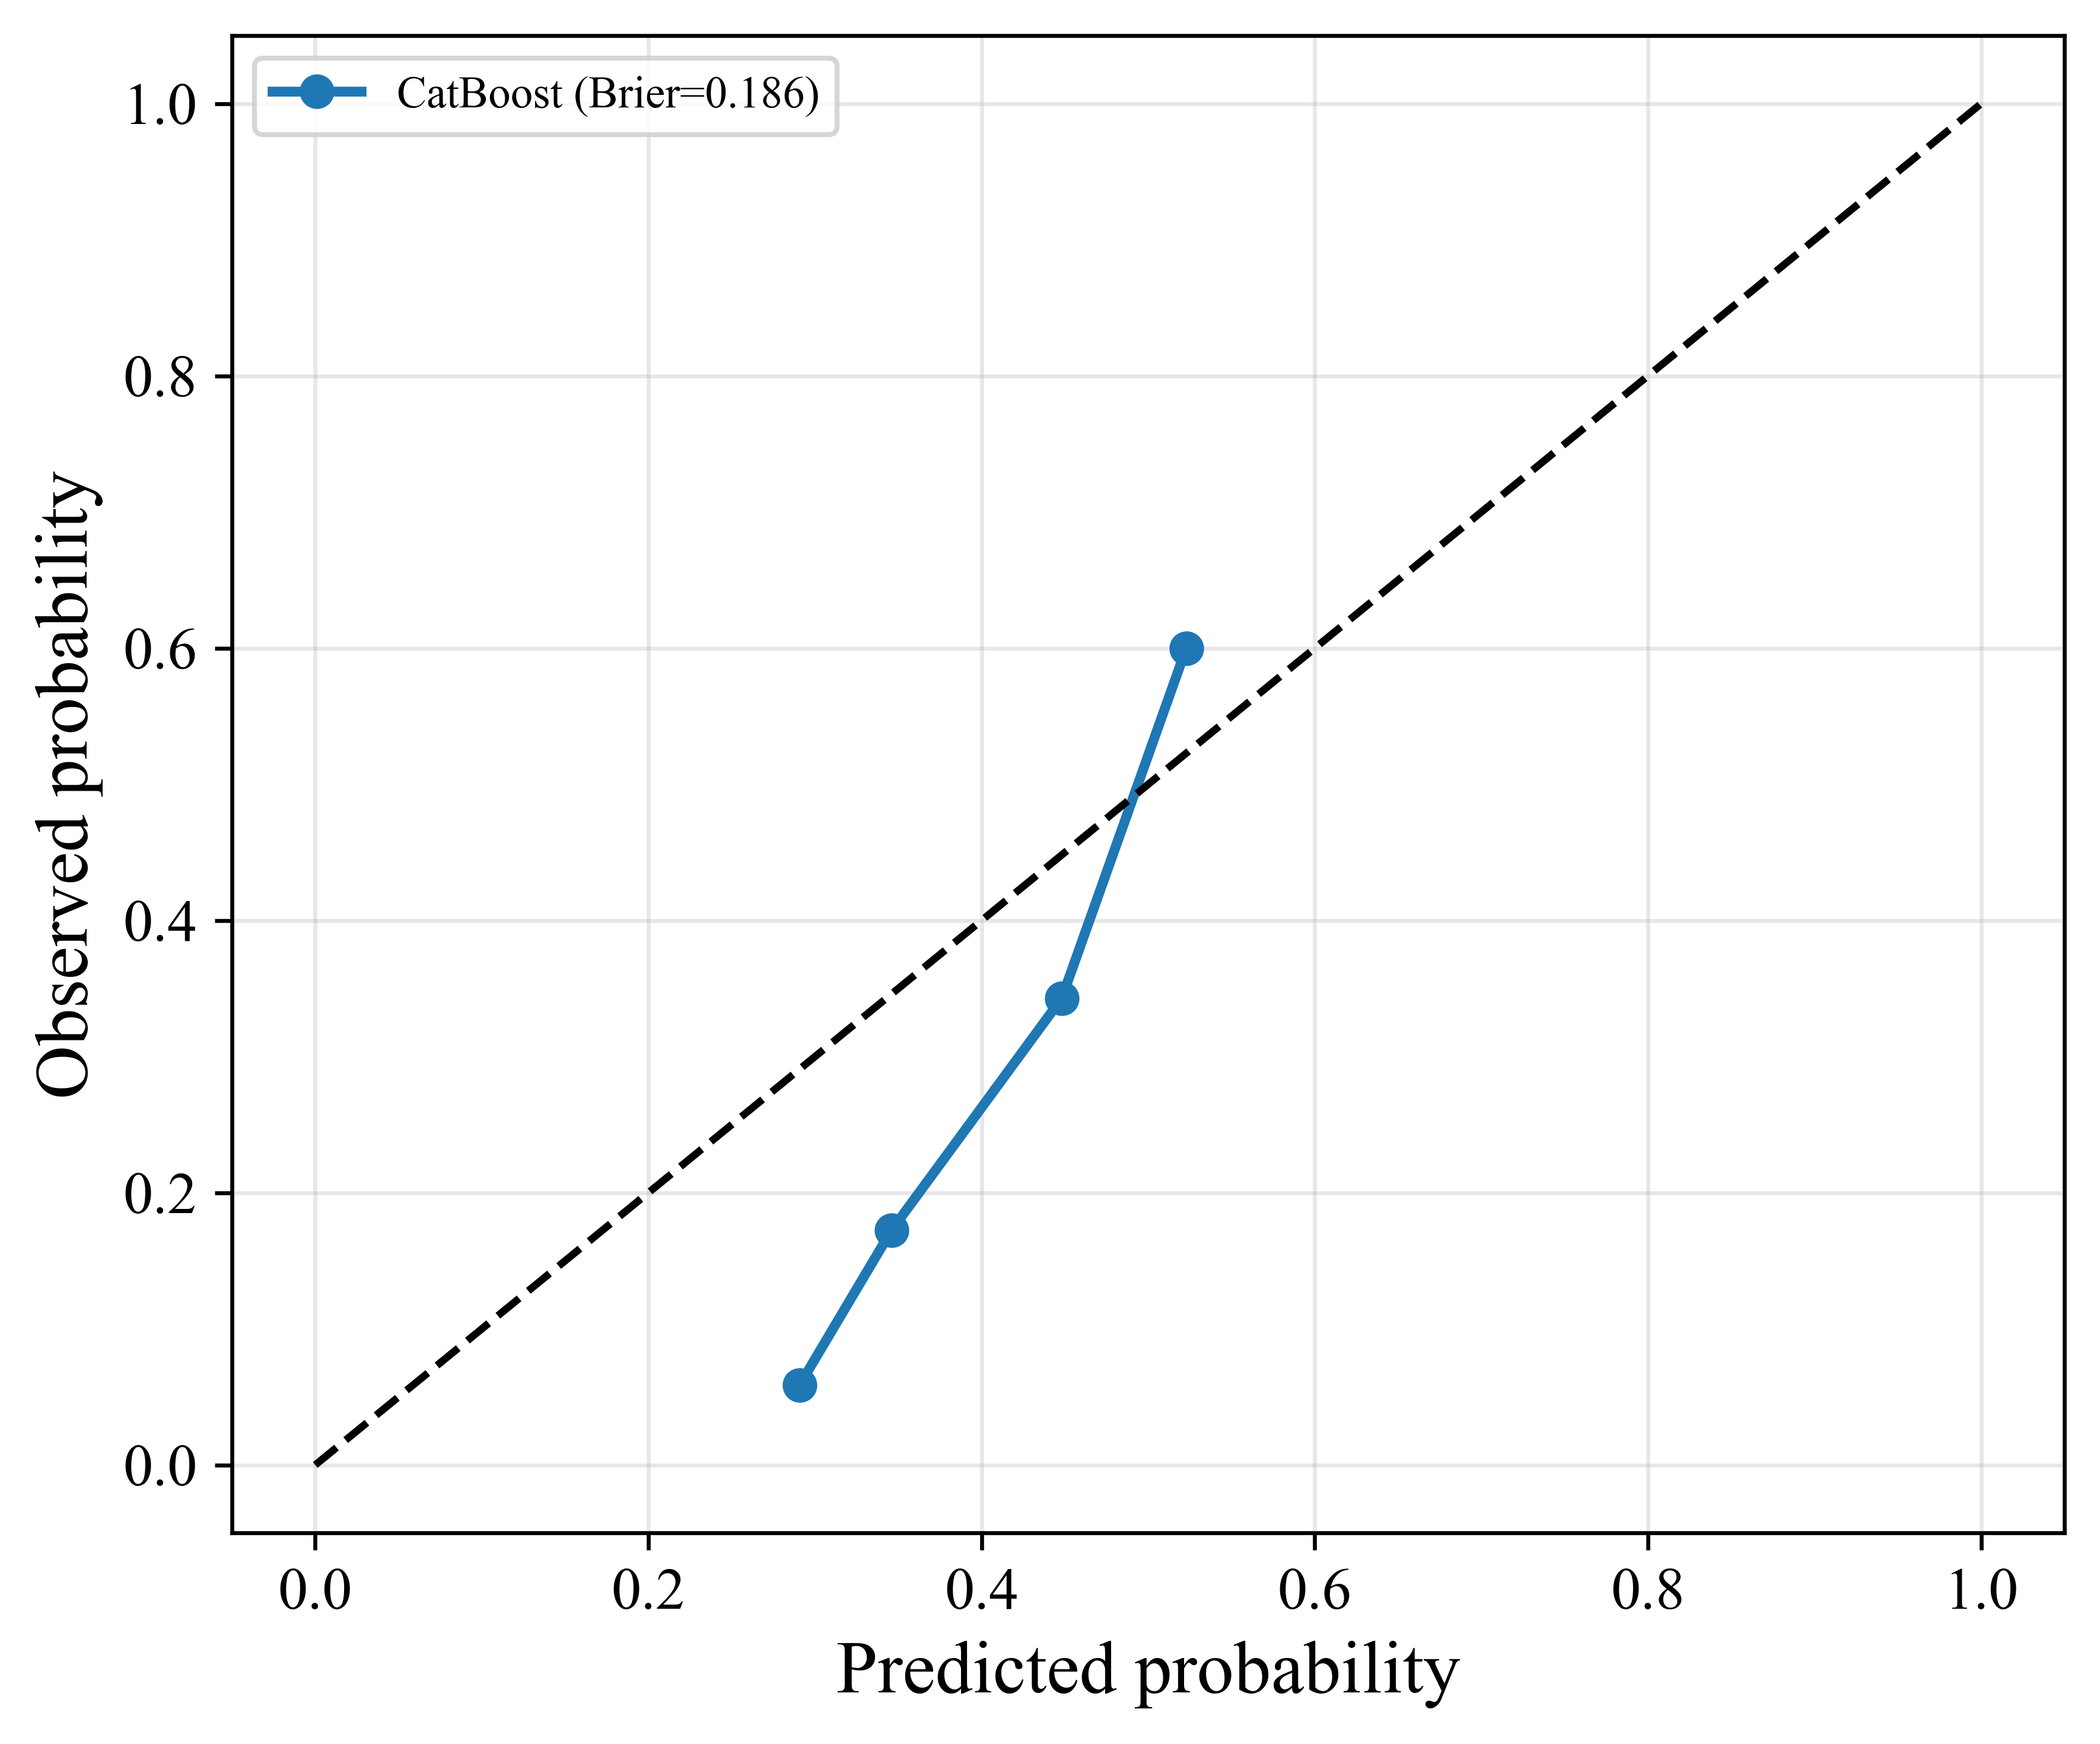

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure3C_calibration.png
  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure3C_calibration.pdf


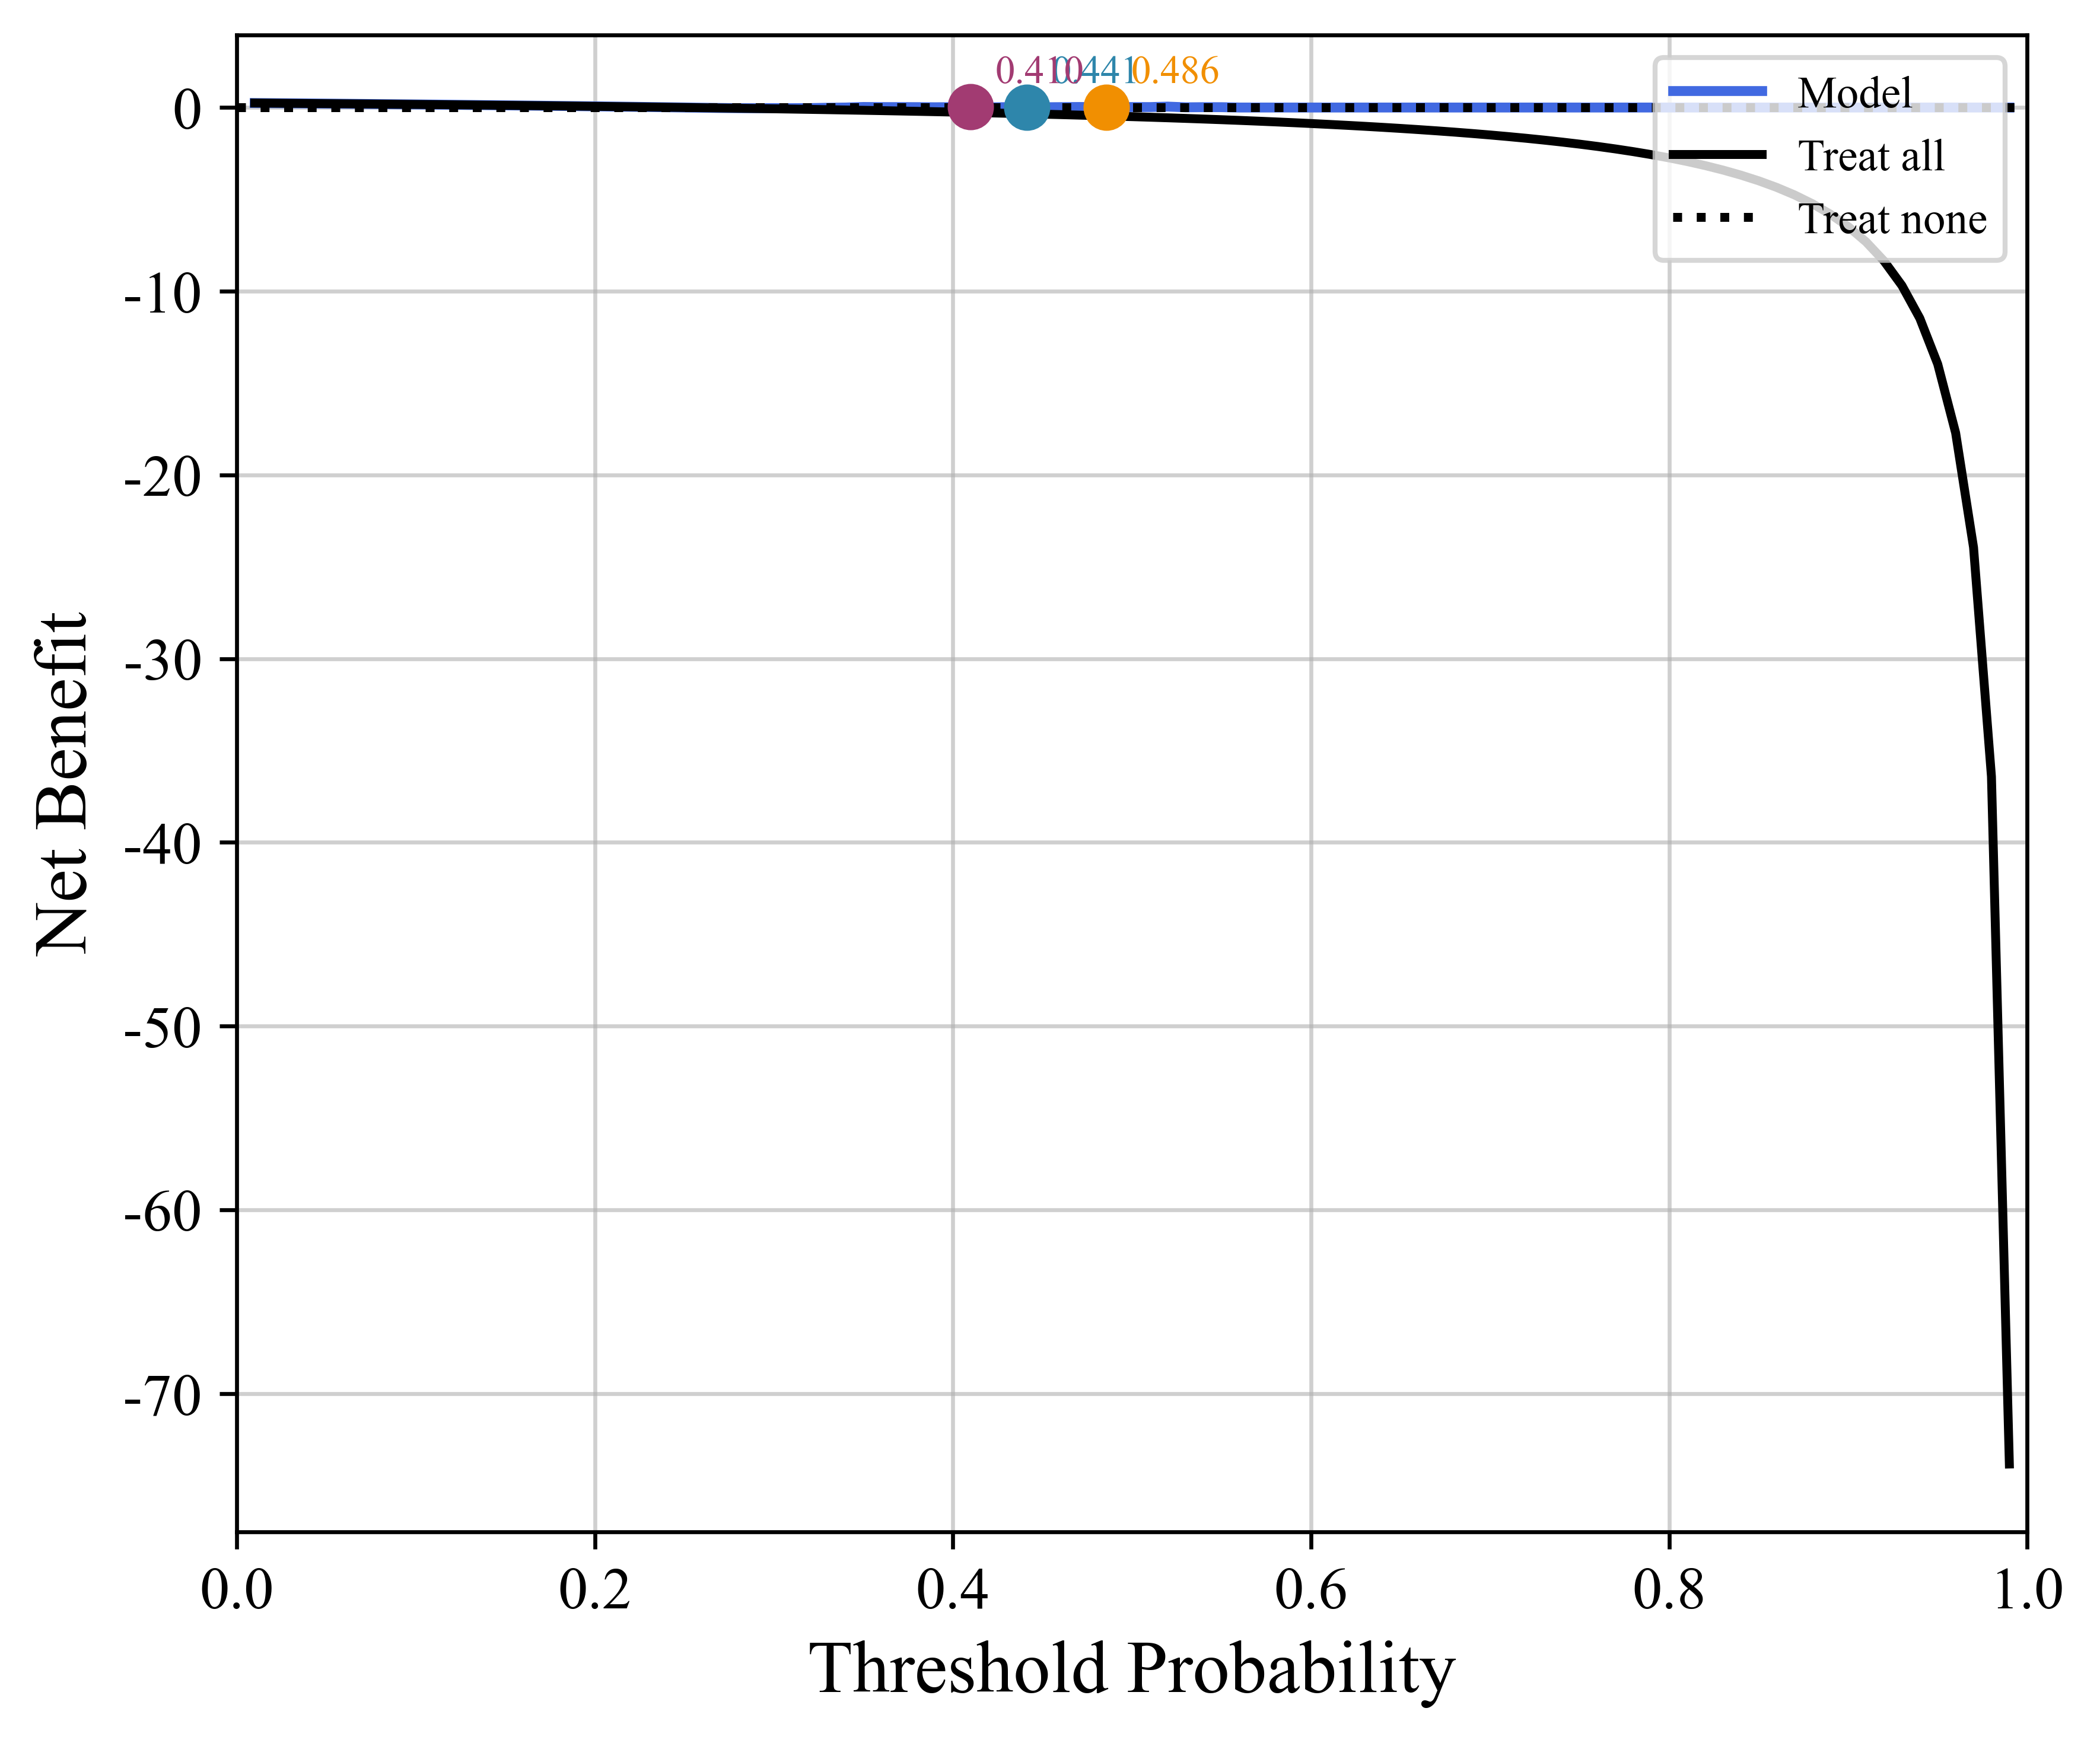

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure3D_DCA.png
  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure3D_DCA.pdf


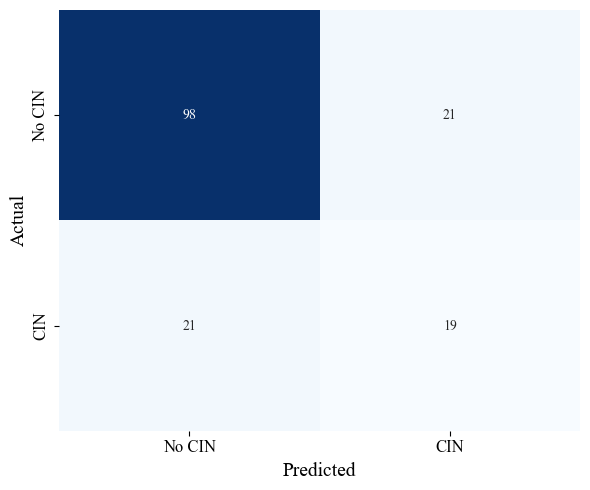

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\SuppFigI_confusion_matrix.png
  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\SuppFigI_confusion_matrix.pdf


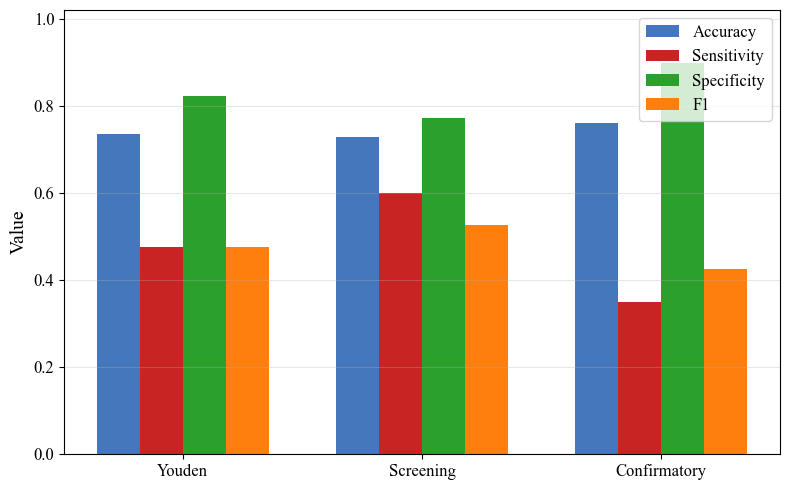

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure_thresholds_summary.png
  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure_thresholds_summary.pdf


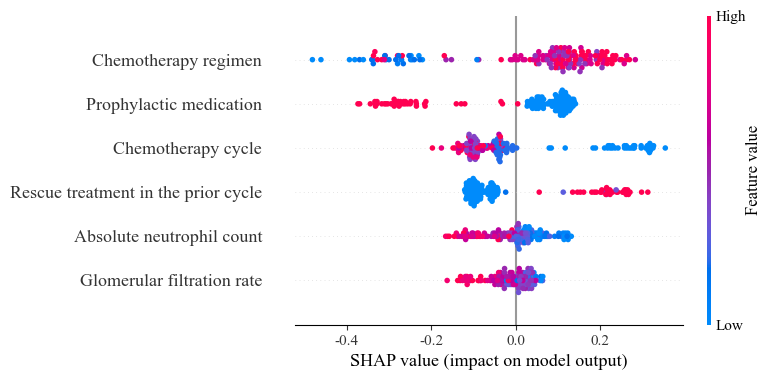

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure5B_SHAP_beeswarm.png
  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure5B_SHAP_beeswarm.pdf


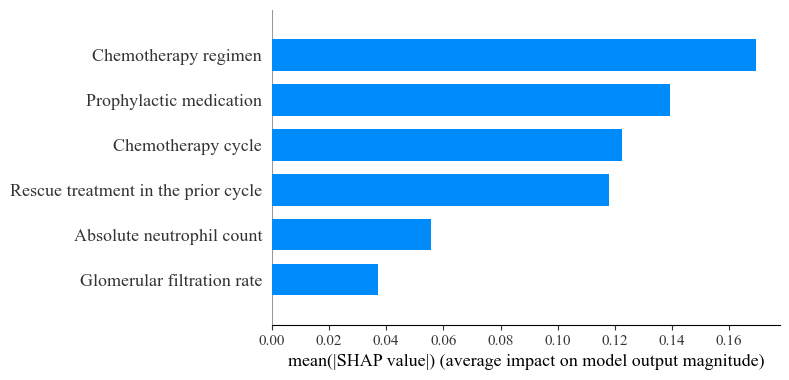

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure5A_SHAP_bar.png
  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure5A_SHAP_bar.pdf


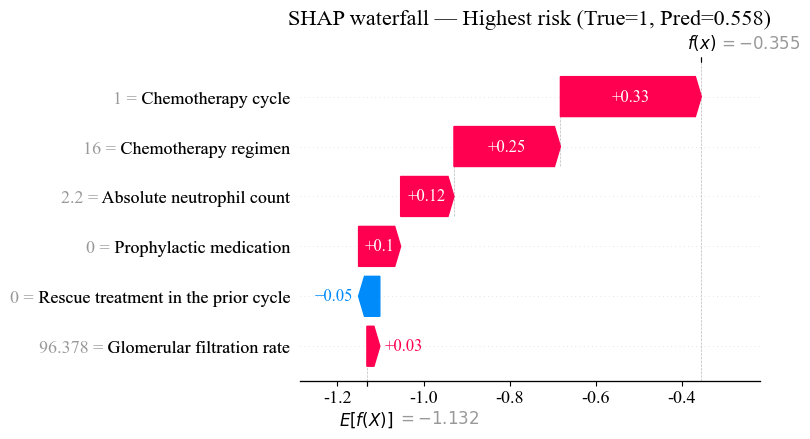

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure7A_SHAP_waterfall_0.png
  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure7A_SHAP_waterfall_0.pdf


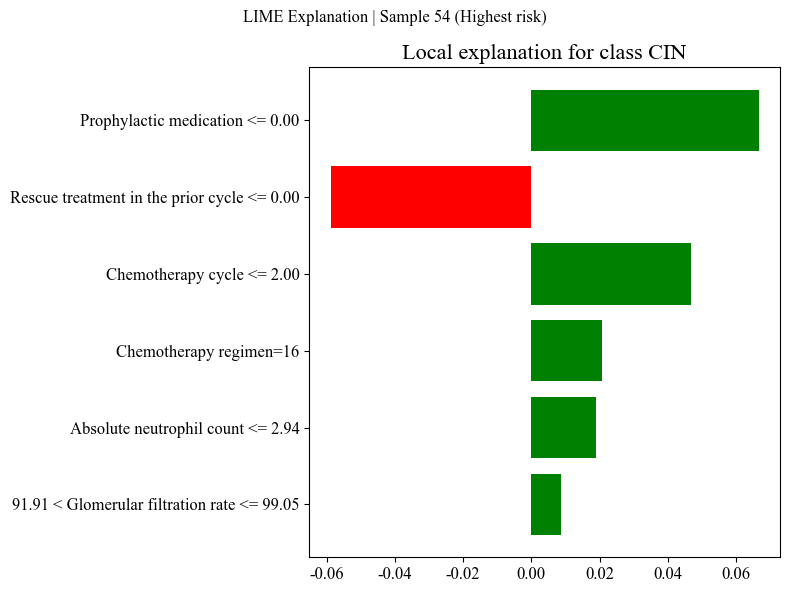

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure7B_LIME_sample0.png
  LIME feature attribution (Sample 54):
    Prophylactic medication <= 0.00  |  weight: 0.0666
    Rescue treatment in the prior cycle <= 0.00  |  weight: -0.0588
    Chemotherapy cycle <= 2.00  |  weight: 0.0468
    Chemotherapy regimen=16  |  weight: 0.0207
    Absolute neutrophil count <= 2.94  |  weight: 0.0189
    91.91 < Glomerular filtration rate <= 99.05  |  weight: 0.0086


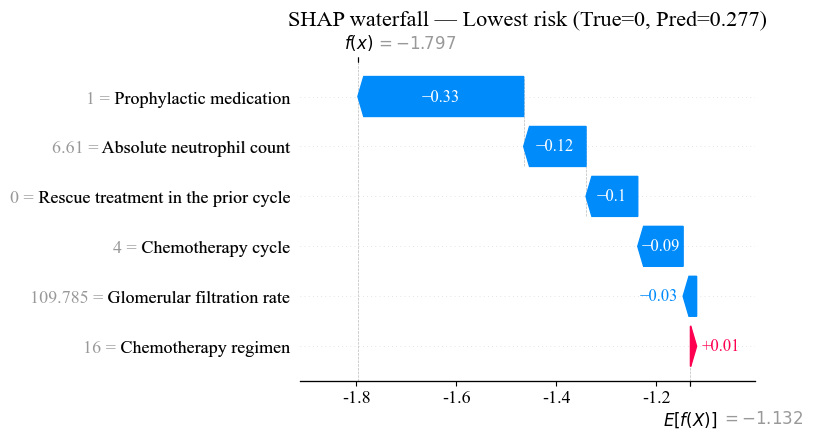

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure7A_SHAP_waterfall_1.png
  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure7A_SHAP_waterfall_1.pdf


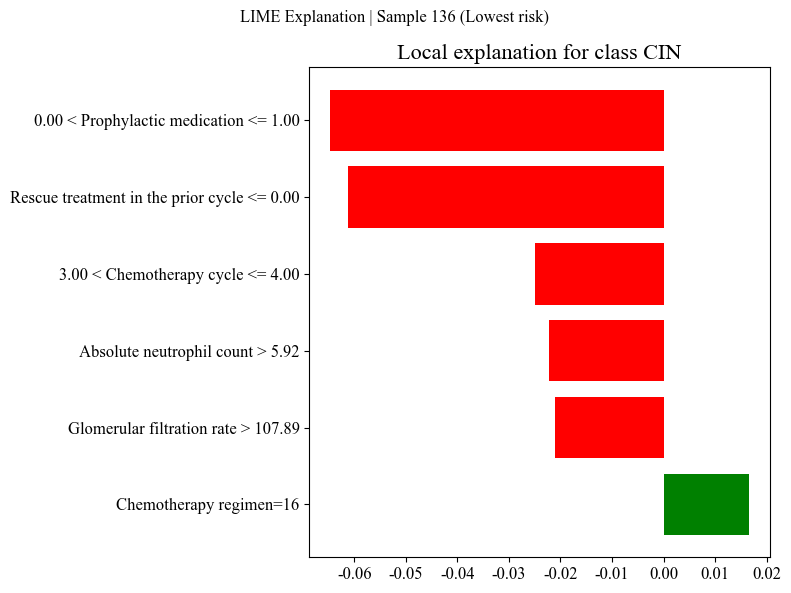

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure7B_LIME_sample1.png
  LIME feature attribution (Sample 136):
    0.00 < Prophylactic medication <= 1.00  |  weight: -0.0647
    Rescue treatment in the prior cycle <= 0.00  |  weight: -0.0612
    3.00 < Chemotherapy cycle <= 4.00  |  weight: -0.0250
    Absolute neutrophil count > 5.92  |  weight: -0.0223
    Glomerular filtration rate > 107.89  |  weight: -0.0210
    Chemotherapy regimen=16  |  weight: 0.0165


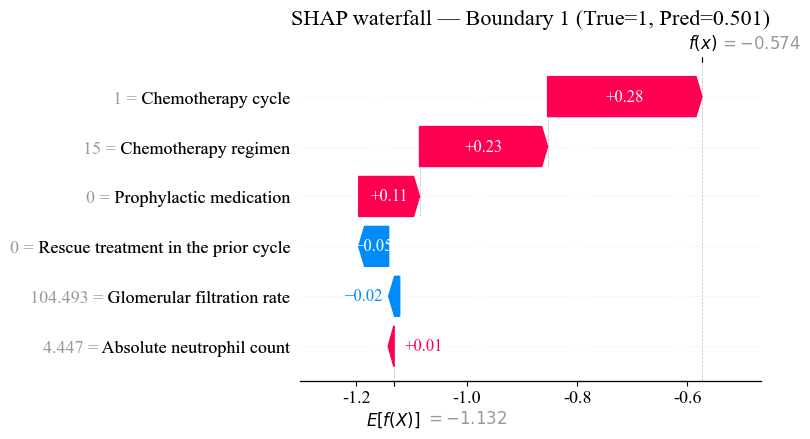

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure7A_SHAP_waterfall_2.png
  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure7A_SHAP_waterfall_2.pdf


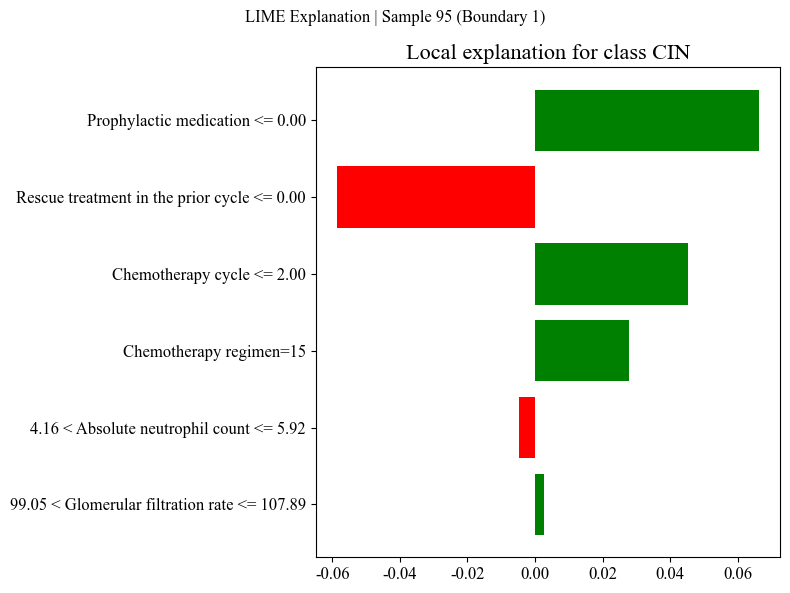

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure7B_LIME_sample2.png
  LIME feature attribution (Sample 95):
    Prophylactic medication <= 0.00  |  weight: 0.0662
    Rescue treatment in the prior cycle <= 0.00  |  weight: -0.0586
    Chemotherapy cycle <= 2.00  |  weight: 0.0454
    Chemotherapy regimen=15  |  weight: 0.0278
    4.16 < Absolute neutrophil count <= 5.92  |  weight: -0.0049
    99.05 < Glomerular filtration rate <= 107.89  |  weight: 0.0028


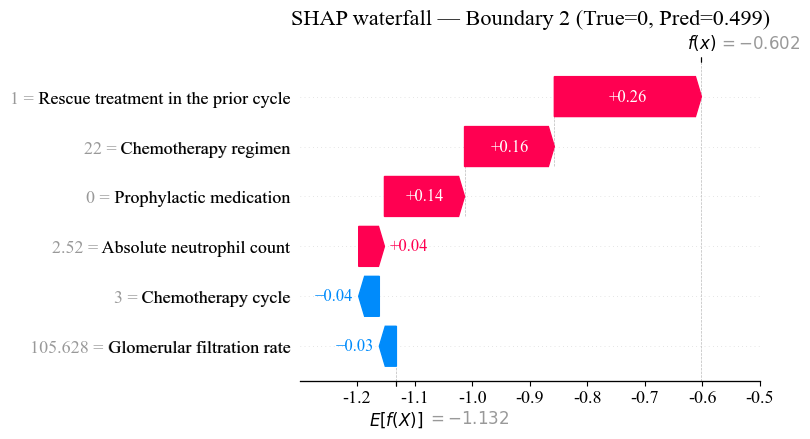

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure7A_SHAP_waterfall_3.png
  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure7A_SHAP_waterfall_3.pdf


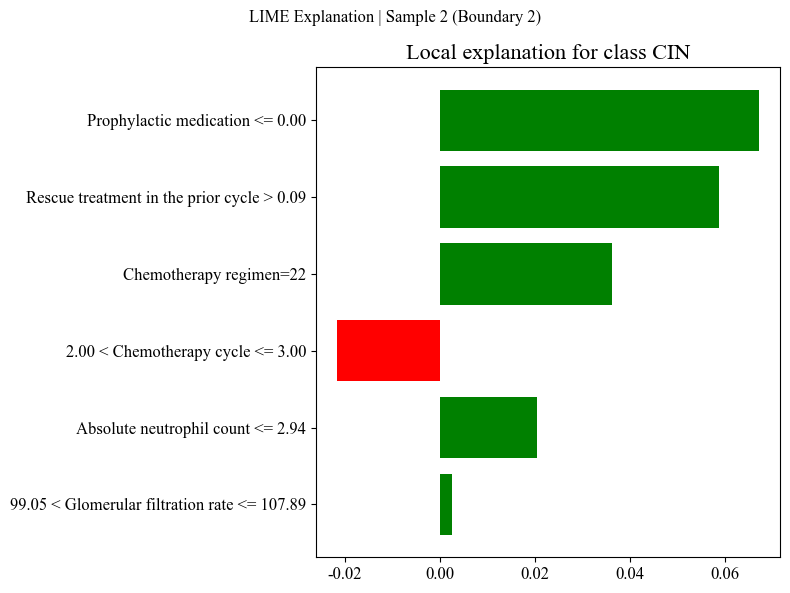

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure7B_LIME_sample3.png
  LIME feature attribution (Sample 2):
    Prophylactic medication <= 0.00  |  weight: 0.0671
    Rescue treatment in the prior cycle > 0.09  |  weight: 0.0586
    Chemotherapy regimen=22  |  weight: 0.0362
    2.00 < Chemotherapy cycle <= 3.00  |  weight: -0.0217
    Absolute neutrophil count <= 2.94  |  weight: 0.0203
    99.05 < Glomerular filtration rate <= 107.89  |  weight: 0.0025


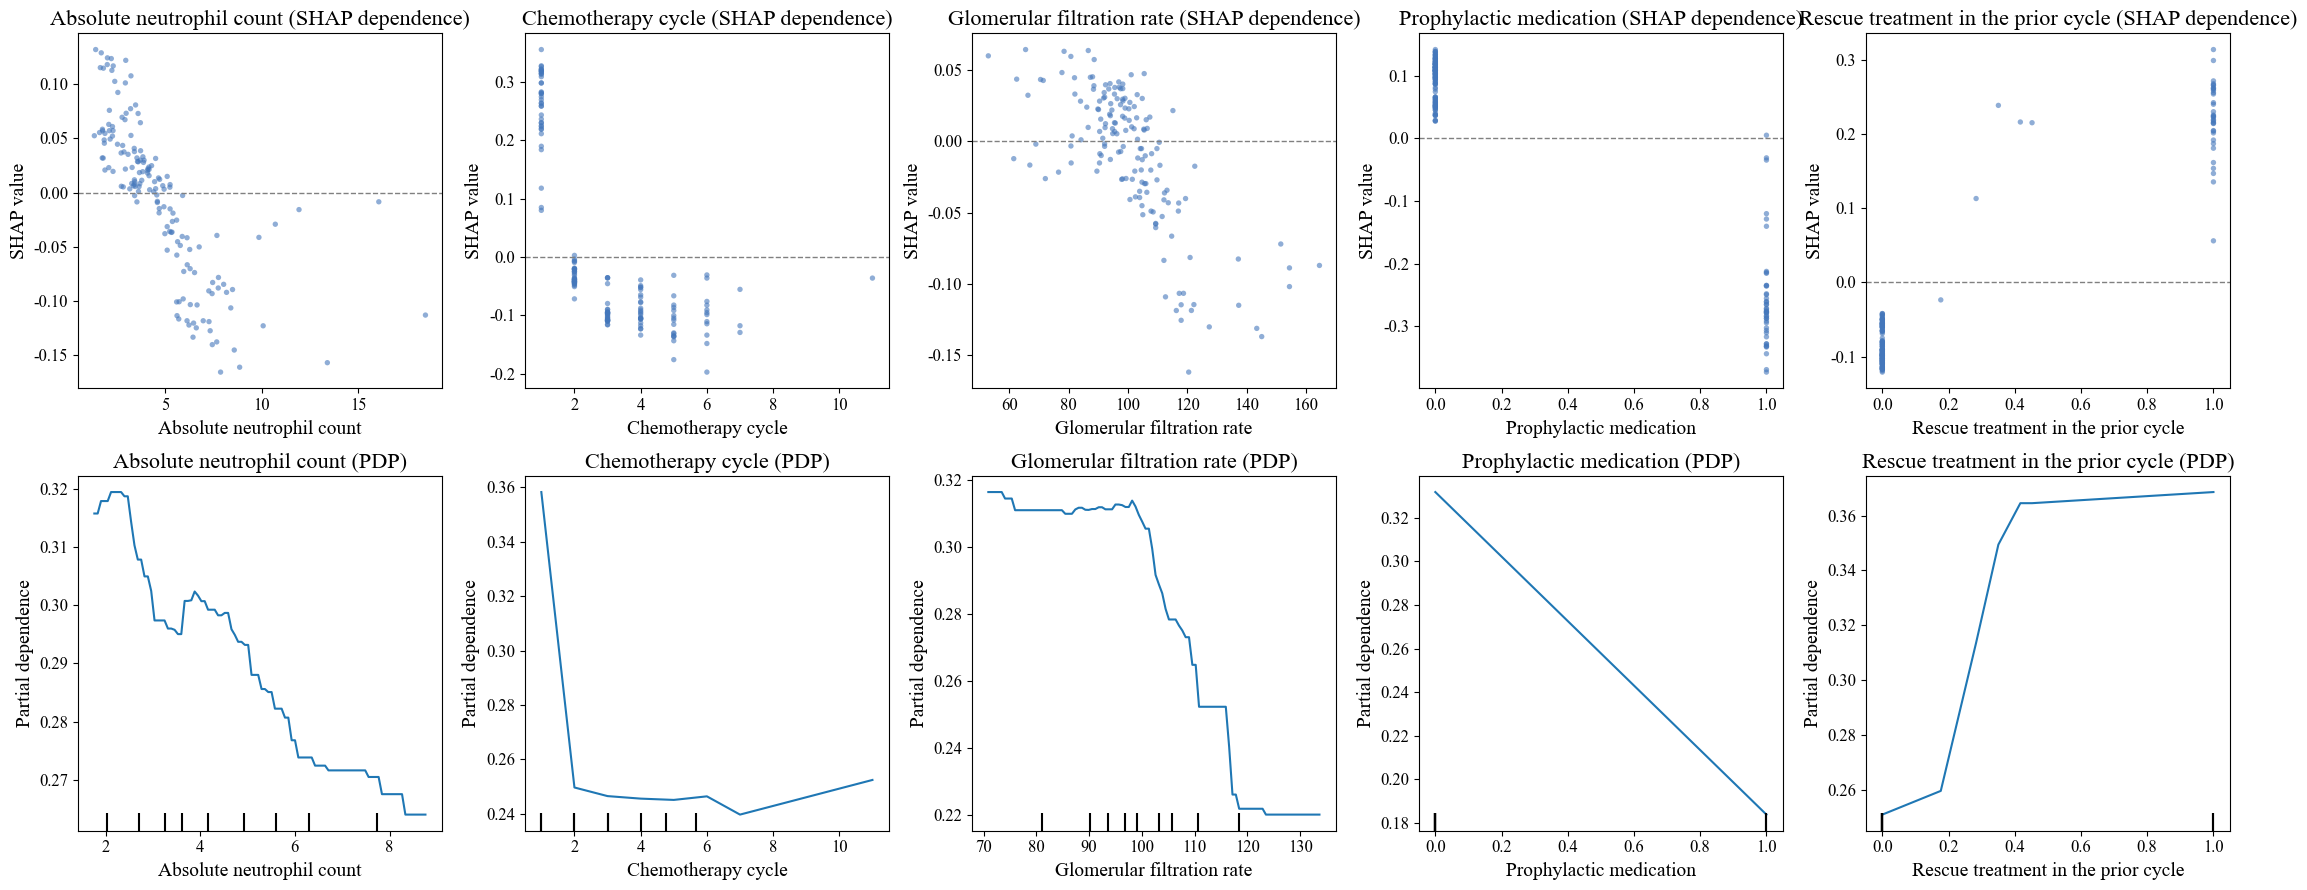

  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure6_scatter_pdp.png
  [Saved] c:\Users\21738\Documents\同步所需\SCLC\程序\Figure6_scatter_pdp.pdf

最终汇总指标：
                metric    value      std            ci
Internal 5-fold CV AUC 0.767343 0.014253           NaN
               OOF AUC 0.700791      NaN           NaN
              Test AUC 0.752101      NaN 0.6898-0.8158
            Test AUPRC 0.555408      NaN 0.4479-0.6501
           Sensitivity 0.475000      NaN           NaN
           Specificity 0.823529      NaN           NaN
                   PPV 0.475000      NaN           NaN
                   NPV 0.823529      NaN           NaN
              Accuracy 0.735849      NaN           NaN
                    F1 0.475000      NaN           NaN
                 Brier 0.186454      NaN           NaN

全流程复现完成 ✅ 耗时 4.9 min


In [8]:
print("\n[Step 5] 生成图表...")
thr_colors = ["#2E86AB", "#A23B72", "#F18F01"]
thr_vals = [youden_thr, high_sens_thr, high_spec_thr]

# ROC + PR
fig = plt.figure(figsize=(12, 5), dpi=600)
ax1 = plt.subplot(1, 2, 1)
ax1.plot(fpr, tpr, linewidth=2, label=f"CatBoost (AUC={test_auc:.3f}, 95% CI [{auc_ci[0]:.3f}-{auc_ci[1]:.3f}])")
for tval, tcol in zip(thr_vals, thr_colors):
    _, _, _, _, tsens, tspec, _, _, _, _ = thr_metrics(y_test, proba_ens, tval)
    ax1.scatter(1 - tspec, tsens, c=tcol, s=70, zorder=6)
    ax1.annotate(f"{tval:.3f}", (1 - tspec, tsens), xytext=(5, 5), textcoords="offset points", fontsize=8, color=tcol)
ax1.plot([0, 1], [0, 1], "k--", linewidth=1.5)
ax1.set_xlabel("False Positive Rate", fontsize=12)
ax1.set_ylabel("True Positive Rate", fontsize=12)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(True, alpha=0.3)
ax2 = plt.subplot(1, 2, 2)
pr_prec, pr_rec, _ = precision_recall_curve(y_test, proba_ens)
ax2.plot(pr_rec, pr_prec, linewidth=2, label=f"CatBoost (AUPRC={test_auprc:.3f})")
ax2.axhline(y_test.mean(), color="black", linestyle="--", linewidth=1.5)
ax2.set_xlabel("Recall", fontsize=12)
ax2.set_ylabel("Precision", fontsize=12)
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True, alpha=0.3)
plt.tight_layout(); save_fig("Figure3B_ROC_PR")

# 校准曲线
frac_pos, mean_pred = calibration_curve(y_test, proba_ens, n_bins=10)
fig = plt.figure(figsize=(6, 5), dpi=600)
plt.plot(mean_pred, frac_pos, marker='o', linewidth=2, label=f"CatBoost (Brier={brier:.3f})")
plt.plot([0, 1], [0, 1], '--', color="black", linewidth=1.5)
plt.xlabel('Predicted probability', fontsize=15)
plt.ylabel('Observed probability', fontsize=15)
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout(); save_fig("Figure3C_calibration")

# DCA
def dca_curve(yt, pr):
    y = yt.values.astype(int); n = len(y); prev = y.mean()
    pts = np.linspace(0.01, 0.99, 99); nb_model = []
    for pt in pts:
        pred = (pr >= pt).astype(int); tp = ((pred==1)&(y==1)).sum(); fp = ((pred==1)&(y==0)).sum()
        nb_model.append((tp - fp*pt/(1-pt))/n)
    nb_all = prev - (1-prev)*pts/(1-pts)
    return pts, np.array(nb_model), nb_all
pts, nb_m, nb_all = dca_curve(y_test, proba_ens)
fig = plt.figure(figsize=(6, 5), dpi=600)
plt.plot(pts, nb_m, color='royalblue', linewidth=2, label="Model")
plt.plot(pts, nb_all, color='black', linewidth=1.8, label="Treat all")
plt.plot((0, 1), (0, 0), color='black', linestyle=':', linewidth=1.8, label="Treat none")
for tval, tcol in zip(thr_vals, thr_colors):
    idx = np.argmin(np.abs(pts - tval))
    plt.scatter(tval, nb_m[idx], c=tcol, s=70, zorder=6)
    plt.annotate(f"{tval:.3f}", (tval, nb_m[idx]), xytext=(5, 5), textcoords="offset points", fontsize=8, color=tcol)
plt.xlim(0, 1)
plt.xlabel('Threshold Probability', fontsize=15)
plt.ylabel('Net Benefit', fontsize=15)
plt.grid(True, alpha=0.6)
plt.legend(loc='upper right', prop={'size': 9})
plt.tight_layout(); save_fig("Figure3D_DCA")

# 混淆矩阵
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(np.array([[tn, fp], [fn, tp]]), annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No CIN", "CIN"], yticklabels=["No CIN", "CIN"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); save_fig("SuppFigI_confusion_matrix")

# 阈值汇总图
thr_names = ["Youden", "Screening", "Confirmatory"]
acc_v, sens_v, spec_v, f1_v = [], [], [], []
for tval in thr_vals:
    _, _, _, _, s, sp, _, _, a, f = thr_metrics(y_test, proba_ens, tval)
    acc_v.append(a); sens_v.append(s); spec_v.append(sp); f1_v.append(f)
x = np.arange(len(thr_names)); width = 0.18
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - 1.5*width, acc_v, width, label="Accuracy", color="#4477bb")
ax.bar(x - 0.5*width, sens_v, width, label="Sensitivity", color="#c82423")
ax.bar(x + 0.5*width, spec_v, width, label="Specificity", color="#2ca02c")
ax.bar(x + 1.5*width, f1_v, width, label="F1", color="#ff7f0e")
ax.set_xticks(x); ax.set_xticklabels(thr_names)
ax.set_ylabel("Value"); ax.set_ylim(0, 1.02)
ax.legend(); ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); save_fig("Figure_thresholds_summary")

# SHAP 汇总图 + 条形图
shap_sum = None
for m in fold_models:
    contrib = m.get_feature_importance(type="ShapValues", data=Pool(X_te_ref, cat_features=cat_ids))
    shap_sum = contrib[:, :-1] if shap_sum is None else shap_sum + contrib[:, :-1]
shap_mean = shap_sum / len(fold_models)
fig = plt.figure(figsize=(8, 6))
shap.summary_plot(shap_mean, X_te_ref.values, feature_names=features, show=False)
plt.tight_layout(); save_fig("Figure5B_SHAP_beeswarm")
fig = plt.figure(figsize=(8, 5))
shap.summary_plot(shap_mean, X_te_ref.values, feature_names=features, plot_type="bar", show=False)
plt.tight_layout(); save_fig("Figure5A_SHAP_bar")

# Figure 7：个体解释（SHAP 瀑布图 + LIME）
explainer = lime_tabular.LimeTabularExplainer(
    X_te_ref.values, feature_names=features, class_names=["No CIN", "CIN"],
    categorical_features=cat_ids, mode="classification",
    random_state=RANDOM_STATE)

def predict_ens_proba(X_arr):
    X_df = pd.DataFrame(X_arr, columns=features)
    for i in cat_ids: X_df[features[i]] = X_df[features[i]].astype(int)
    p1 = np.mean([m.predict_proba(X_df)[:, 1] for m in fold_models], axis=0)
    return np.column_stack([1 - p1, p1])

order = np.argsort(proba_ens)[::-1]
sample_idx = [order[0], order[-1]]
boundary_idx = np.argsort(np.abs(proba_ens - 0.5))[:2]
sample_idx = list(dict.fromkeys(sample_idx + list(boundary_idx)))
sample_labels = ["Highest risk", "Lowest risk", "Boundary 1", "Boundary 2"]
for rank, idx in enumerate(sample_idx):
    single = Pool(X_te_ref.iloc[[idx]], cat_features=cat_ids)
    shap_sum_i = None
    for m in fold_models:
        sv = m.get_feature_importance(type="ShapValues", data=single)
        shap_sum_i = sv[:, :-1] if shap_sum_i is None else shap_sum_i + sv[:, :-1]
    shap_sample = (shap_sum_i / len(fold_models))[0]
    base = fold_models[0].get_feature_importance(type="ShapValues", data=single)[0, -1]
    expl = shap.Explanation(values=shap_sample, base_values=base,
                            data=X_te_ref.iloc[idx].values, feature_names=features)
    plt.figure()
    shap.waterfall_plot(expl, max_display=len(features), show=False)
    plt.title(f"SHAP waterfall — {sample_labels[rank]} (True={y_test.iloc[idx]}, Pred={proba_ens[idx]:.3f})")
    plt.tight_layout()
    save_fig(f"Figure7A_SHAP_waterfall_{rank}")

    exp = explainer.explain_instance(X_te_ref.values[idx], predict_ens_proba, num_features=len(features))
    exp.save_to_file(f"Figure7B_LIME_sample{rank}.html")
    lime_fig = exp.as_pyplot_figure()
    lime_fig.set_size_inches(8, 6)
    lime_fig.suptitle(f"LIME Explanation | Sample {idx} ({sample_labels[rank]})", fontfamily="Times New Roman")
    lime_fig.tight_layout()
    lime_png = os.path.join(os.getcwd(), f"Figure7B_LIME_sample{rank}.png")
    lime_fig.savefig(lime_png, dpi=600, bbox_inches="tight")
    if _in_notebook:
        from IPython.display import display
        display(lime_fig)
    plt.close(lime_fig)
    print(f"  [Saved] {lime_png}")
    print(f"  LIME feature attribution (Sample {idx}):")
    for feature_desc, weight in exp.as_list():
        print(f"    {feature_desc}  |  weight: {weight:.4f}")

# Figure 6：SHAP 依赖散点 + PDP
cont_features = [i for i, c in enumerate(features) if c not in CATEGORY_COLS]
if cont_features:
    n = len(cont_features)
    fig, axes = plt.subplots(2, n, figsize=(4.5 * n, 9))
    if n == 1: axes = axes.reshape(2, 1)
    for j, fi in enumerate(cont_features):
        c = features[fi]
        ax = axes[0, j]
        ax.scatter(X_te_ref[c], shap_mean[:, fi], s=15, alpha=0.6, c="#4477bb", edgecolors="none")
        ax.axhline(0, ls="--", color="gray", lw=1)
        ax.set_xlabel(c); ax.set_ylabel("SHAP value")
        ax.set_title(f"{c} (SHAP dependence)")
        ax = axes[1, j]
        PartialDependenceDisplay.from_estimator(
            fold_models[0], X_te_ref, features=[fi], ax=ax, kind="average",
            response_method="predict_proba", n_jobs=4)
        ax.set_title(f"{c} (PDP)")
    plt.tight_layout(); save_fig("Figure6_scatter_pdp")

# 汇总表
summary = pd.DataFrame([
    {"metric": "Internal 5-fold CV AUC", "value": cv_auc, "std": cv_std},
    {"metric": "OOF AUC", "value": oof_auc},
    {"metric": "Test AUC", "value": test_auc, "ci": f"{auc_ci[0]:.4f}-{auc_ci[1]:.4f}"},
    {"metric": "Test AUPRC", "value": test_auprc, "ci": f"{auprc_ci[0]:.4f}-{auprc_ci[1]:.4f}"},
    {"metric": "Sensitivity", "value": sens},
    {"metric": "Specificity", "value": spec},
    {"metric": "PPV", "value": ppv}, {"metric": "NPV", "value": npv},
    {"metric": "Accuracy", "value": acc}, {"metric": "F1", "value": f1},
    {"metric": "Brier", "value": brier},
])
summary.to_excel("final_summary_metrics.xlsx", index=False)
print("\n" + "=" * 70)
print("最终汇总指标：")
print(summary.to_string(index=False))
print("=" * 70)
print(f"\n全流程复现完成 ✅ 耗时 {(time.time()-t0)/60:.1f} min")